In [10]:
import numpy as np
import matplotlib.pyplot as plt

from astropy import units as u

from prism.data import Spectrum
import prism.modeling.models as models
import prism.modeling.fitting as fitting
from prism.modeling.fitting import tie
import prism.modeling.display # importing the display module to enable the model display features

plt.rcParams['axes.xmargin'] = 0

In [11]:
filename = 'data/agnspec.txt'

# (Optional) Set the source coordinates and redshift
dec, ra = -25.12345, 13.12345
redshift = 0.0622

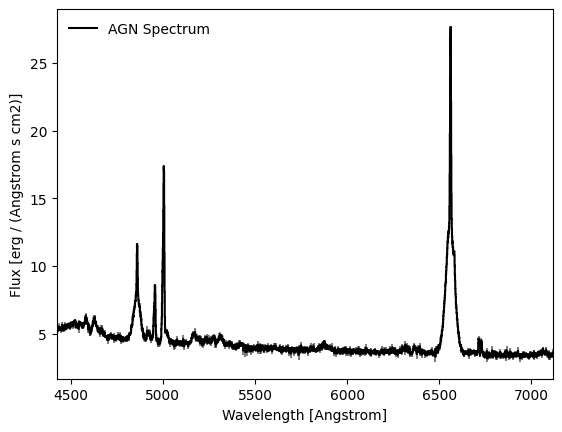

In [12]:
spec = Spectrum.from_txt(filename=filename,
                         ra=ra,
                         dec=dec,
                         z=redshift,
                         wave_unit=u.AA,
                         unit=1e-15 * u.erg / (u.s * u.cm**2 * u.AA),
                         name='AGN Spectrum')

# # (Example) Mask a region
# wmask = (spec.wave <= 5800) | (spec.wave >= 5980)
# spec.crop(wmask=wmask)

# # (Example) Crop a portion of the spectrum
# wbounds = (4800., 7500.) # Å
# spec.crop(wbounds=wbounds)

# Apply Galactic extinction correction
spec.deredden()

# (Optional) Apply redshift correction to rest frame
spec.zcorrect()

spec.plot_spectrum() 

In [13]:
# (Optional) Copy locally the CSV file containing the line list, and set up the local line database.
models.setup_local_lines(wmin=np.min(spec.wave), wmax=np.max(spec.wave), overwrite=True)

# # If you want to blindly proceed with the default line list without inspecting it, you can use models.set_wavelength_range()
# # This will just filter the lines to those that fall within the wavelength range of interest.
# models.set_wavelength_range(wmin=np.min(spec.wave), wmax=np.max(spec.wave))

# NOTE: If you decide to work in the observed frame, you should remember to set the line database to the rest frame, i.e. models.set_wavelength_range(wmin=np.min(spec.wave)/(1+redshift), wmax=np.max(spec.wave)/(1+redshift))

Wavelength range set to: [4424.778761061947, 7117.303709282621]


In [14]:
# Line Models support instumental broadening. This can be set to either a constant value (in km/s) or a 2D array with wavelength and FWHM values (in km/s).
# The latter is useful when the instrumental resolution varies significantly across the wavelength range of interest.
# For the sake of simplicity we will use a constant value here, but I leave a snippet below to show how to set up a wavelength-dependent instrumental broadening based on the MUSE instrumental response.

instfwhm = 120. # km/s



# # Set wavelength-dependent instrumental broadening based on the MUSE instrumental response
# from astropy.constants import c
# c_kms = c.to('km/s').value

# # Instrumental Response of MUSE from the MUSE User Manual
# resp_lambda = np.array([4650.0, 5000.0, 5500.0, 6000.0, 6500.0, 7000.0, 7500.0, 8000.0, 8500.0, 9000.0, 9350.0])
# resp_R = np.array([1609, 1750, 1978, 2227, 2484, 2737, 2975, 3183, 3350, 3465, 3506])

# wave_rest = resp_lambda * (1.0 + redshift) # Null the zcorrection for instrumental effects. Not needed if you are working in the observed frame.
# fwhm_km_s = c_kms / resp_R

# instfwhm = np.array([wave_rest, fwhm_km_s]).T

In [15]:
# Setup the model

# Continuum
bknpower = models.BrokenPowerlaw(
    name='bknpower',
    x_ref=5450,
    amplitude=np.median(spec.flux),
    index1=-2.0,
    index2=0.0,
    bounds={
        'x_ref': (5100, 5710),
        'amplitude': (1.5, 5.0),
        'index1': (-3.0, 0.0),
        'index2': (-1.0, 1.5),
    }
)

# Broad Line Region (BLR)
blr = models.agn.blr(
    name='blr',
    amplitude=10,
    offset=-360,
    fwhm=3727,
    instfwhm=instfwhm,
    bounds={
        'amplitude': (0, 1000),
        'offset': (-1000, 1000),
        'fwhm': (500, 8000),
    },
)

# Narrow Line Region (NLR)
nlr = models.agn.nlr(
    name='nlr',
    amplitude=1,
    offset=0,
    fwhm=500,
    instfwhm=instfwhm,
    bounds={
        'amplitude': (0, 100),
        'offset': (-300, 300),
        'fwhm': (0, 800),
    }
)

# Let's add Hydrogen and Helium lines tied to the NLR component. By default they are kept separate.
hhe_nlr = models.GaussianLines.from_csv(
    name='hhe_nlr',
    csv_files=['hydrogen.csv', 'helium.csv'],
    amplitude=1,
    offset=0,
    fwhm=500,
    instfwhm=instfwhm,
    bounds={
        'amplitude': (0, 100),
        'offset': (-300, 300),
        'fwhm': (0, 800),
    }
)
# Link the kinematics of the Hydrogen and Helium lines to those of the NLR component.
hhe_nlr.offset.tied = tie("nlr", lambda m: m.offset)
hhe_nlr.fwhm.tied = tie("nlr", lambda m: m.fwhm)

# OIII outflow
oiii_out = models.GaussianLines.from_csv(
    name='oiii',
    csv_files=['oiii.csv'],
    amplitude=1,
    offset=-560,
    fwhm=850,
    instfwhm=instfwhm,
    bounds={
        'amplitude': (0, 100),
        'offset': (-1000, 750),
        'fwhm': (50, 1500),
    }
)

# FeII Model
fe = models.agn.fe(
    name='fe',
    offset=0,
    fwhm=1200,
    instfwhm=instfwhm,
    bounds={
        'amplitude': (0, 100),
        'offset': (-3000, 3000),
        'fwhm': (800, 3000),
    }
)


# Combine all components
model = bknpower + blr + nlr + hhe_nlr + oiii_out + fe

In [16]:
model

<CompoundModel(bknpower + blr + nlr + hhe_nlr + oiii + fe; amplitude_0=3.92125, x_ref_0=5450, index1_0=-2, index2_0=0, ...)>

In [17]:
print(model)

Expression: bknpower + blr + nlr + hhe_nlr + oiii + fe

Component | Parameter      | Value   | Fixed | Tied | Bounds       
----------+----------------+---------+-------+------+--------------
bknpower  | amplitude_0    | 3.92125 | no    | no   | [1.5, 5]     
bknpower  | x_ref_0        | 5450    | no    | no   | [5100, 5710] 
bknpower  | index1_0       | -2      | no    | no   | [-3, 0]      
bknpower  | index2_0       | 0       | no    | no   | [-1, 1.5]    
blr       | amp_hb4861_1   | 10      | no    | no   | [0, 1000]    
blr       | amp_ha6562_1   | 10      | no    | no   | [0, 1000]    
blr       | amp_hei4471_1  | 10      | no    | no   | [0, 1000]    
blr       | amp_heii4685_1 | 10      | no    | no   | [0, 1000]    
blr       | amp_hei5877_1  | 10      | no    | no   | [0, 1000]    
blr       | amp_hei6678_1  | 10      | no    | no   | [0, 1000]    
blr       | amp_hei7065_1  | 10      | no    | no   | [0, 1000]    
blr       | offset_1       | -360    | no    | no   | [-1000

In [18]:
model.expression

'bknpower + blr + nlr + hhe_nlr + oiii + fe'